In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

In [2]:
# New One
def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    return value


def weighted_cness(G, W):
    edges = list(G.edges())
    w_closeness = []
    for i in range(0, len(edges)):
        closeness = []
        nd_1 = edges[i][0]
        nd_2 = edges[i][1]
        weight_1 = weight_of_a_node(G,nd_1,W)
        weight_2 = weight_of_a_node(G,nd_2,W)
        edge_w = G.get_edge_data(nd_1, nd_2)
        val = edge_w['weight']
        influence_edge_val = (weight_1 + weight_2) * (val/W)
        closeness.append(edges[i])
        closeness.append(influence_edge_val)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_

def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### s_s_1

Name: 
Type: Graph
Number of nodes: 5
Number of edges: 5
Average degree:   2.0000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


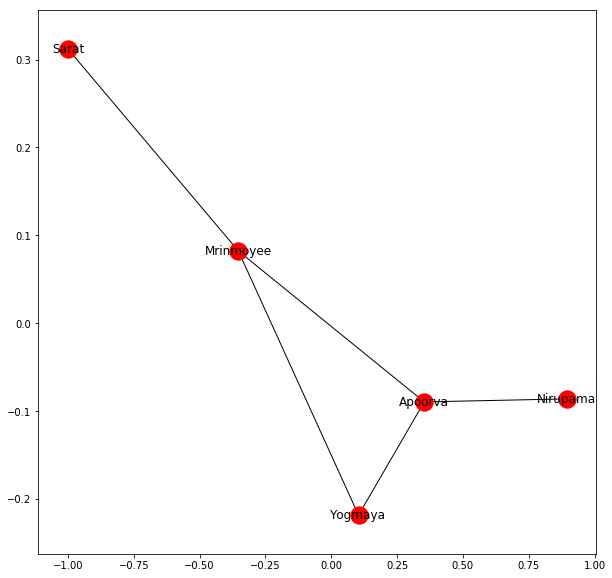

[[('Apoorva', 'Yogmaya'), 1.2307692307692308], [('Apoorva', 'Nirupama'), 0.28402366863905326], [('Apoorva', 'Mrinmoyee'), 0.15384615384615385], [('Yogmaya', 'Mrinmoyee'), 0.15384615384615385], [('Mrinmoyee', 'Sarat'), 0.09467455621301776]]


In [3]:
ss_1 = nx.read_weighted_edgelist('s_s_1.txt', delimiter=',')
print(nx.info(ss_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(ss_1)
plt.show()

total_edge_weight = total_weight_of_G(ss_1) #NCF
w_ncf_1 = weighted_cness(ss_1,total_edge_weight)
print(w_ncf_1)

In [4]:
edge_w = list(w_ncf_1)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                  Edges        IF
0    (Apoorva, Yogmaya)  1.230769
1   (Apoorva, Nirupama)  0.284024
2  (Apoorva, Mrinmoyee)  0.153846
3  (Yogmaya, Mrinmoyee)  0.153846
4    (Mrinmoyee, Sarat)  0.094675
         IF
0  0.957641
1  0.220994
2  0.119705
3  0.119705
4  0.073665


### s_s_2

Name: 
Type: Graph
Number of nodes: 9
Number of edges: 11
Average degree:   2.4444


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


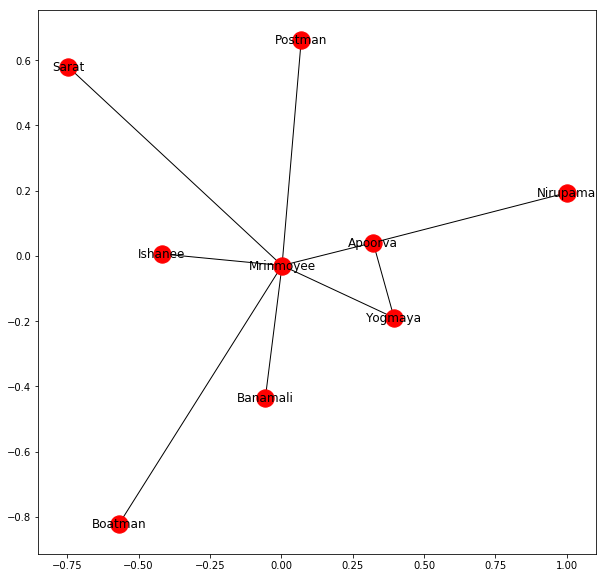

[[('Apoorva', 'Yogmaya'), 0.356401384083045], [('Apoorva', 'Apoorva'), 0.039984621299500187], [('Apoorva', 'Mrinmoyee'), 0.6520569011918492], [('Apoorva', 'Nirupama'), 0.06151480199923106], [('Yogmaya', 'Mrinmoyee'), 0.2018454440599769], [('Mrinmoyee', 'Mrinmoyee'), 0.1245674740484429], [('Mrinmoyee', 'Ishanee'), 0.17877739331026526], [('Mrinmoyee', 'Postman'), 0.07151095732410612], [('Mrinmoyee', 'Boatman'), 0.03575547866205306], [('Mrinmoyee', 'Banamali'), 0.21453287197231832], [('Mrinmoyee', 'Sarat'), 0.03575547866205306]]


In [5]:
ss_2 = nx.read_weighted_edgelist('s_s_2.txt', delimiter=',')
print(nx.info(ss_2))

plt.figure(figsize = (10,10))
nx.draw_networkx(ss_2)
plt.show()

total_edge_weight = total_weight_of_G(ss_2) #NCF
w_ncf_2 = weighted_cness(ss_2,total_edge_weight)
print(w_ncf_2)

In [6]:
edge_w = list(w_ncf_2)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                     Edges        IF
0       (Apoorva, Yogmaya)  0.356401
1       (Apoorva, Apoorva)  0.039985
2     (Apoorva, Mrinmoyee)  0.652057
3      (Apoorva, Nirupama)  0.061515
4     (Yogmaya, Mrinmoyee)  0.201845
5   (Mrinmoyee, Mrinmoyee)  0.124567
6     (Mrinmoyee, Ishanee)  0.178777
7     (Mrinmoyee, Postman)  0.071511
8     (Mrinmoyee, Boatman)  0.035755
9    (Mrinmoyee, Banamali)  0.214533
10      (Mrinmoyee, Sarat)  0.035755
          IF
0   0.426134
1   0.047808
2   0.779637
3   0.073551
4   0.241338
5   0.148940
6   0.213757
7   0.085503
8   0.042751
9   0.256508
10  0.042751


### s_s_3

Name: 
Type: Graph
Number of nodes: 9
Number of edges: 11
Average degree:   2.4444


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


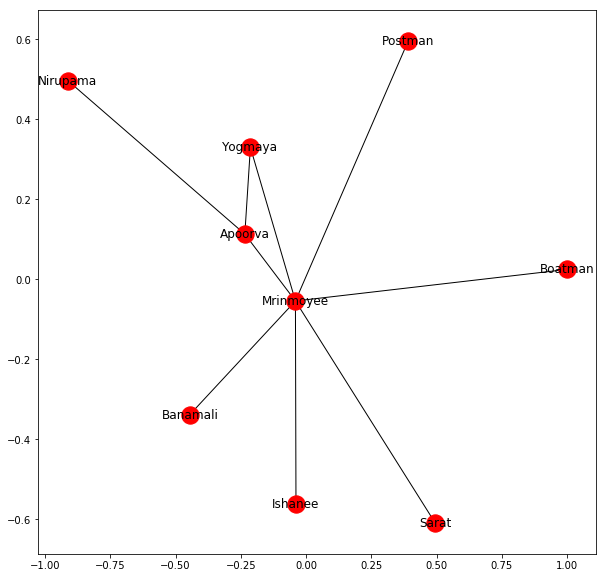

[[('Mrinmoyee', 'Mrinmoyee'), 0.20595155709342564], [('Mrinmoyee', 'Yogmaya'), 0.12318339100346021], [('Mrinmoyee', 'Apoorva'), 0.8919031141868512], [('Mrinmoyee', 'Ishanee'), 0.10934256055363321], [('Mrinmoyee', 'Postman'), 0.043737024221453286], [('Mrinmoyee', 'Boatman'), 0.021868512110726643], [('Mrinmoyee', 'Banamali'), 0.13121107266435986], [('Mrinmoyee', 'Sarat'), 0.043737024221453286], [('Apoorva', 'Yogmaya'), 0.4023529411764706], [('Apoorva', 'Apoorva'), 0.023806228373702422], [('Apoorva', 'Nirupama'), 0.03930795847750865]]


In [7]:
ss_3 = nx.read_weighted_edgelist('s_s_3.txt', delimiter=',')
print(nx.info(ss_3))

plt.figure(figsize = (10,10))
nx.draw_networkx(ss_3)
plt.show()

total_edge_weight = total_weight_of_G(ss_3) #NCF
w_ncf_3 = weighted_cness(ss_3,total_edge_weight)
print(w_ncf_3)

In [8]:
edge_w = list(w_ncf_3)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)\

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                     Edges        IF
0   (Mrinmoyee, Mrinmoyee)  0.205952
1     (Mrinmoyee, Yogmaya)  0.123183
2     (Mrinmoyee, Apoorva)  0.891903
3     (Mrinmoyee, Ishanee)  0.109343
4     (Mrinmoyee, Postman)  0.043737
5     (Mrinmoyee, Boatman)  0.021869
6    (Mrinmoyee, Banamali)  0.131211
7       (Mrinmoyee, Sarat)  0.043737
8       (Apoorva, Yogmaya)  0.402353
9       (Apoorva, Apoorva)  0.023806
10     (Apoorva, Nirupama)  0.039308
          IF
0   0.200935
1   0.120183
2   0.870177
3   0.106679
4   0.042672
5   0.021336
6   0.128015
7   0.042672
8   0.392552
9   0.023226
10  0.038350


### s_s_4

Name: 
Type: Graph
Number of nodes: 12
Number of edges: 15
Average degree:   2.5000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


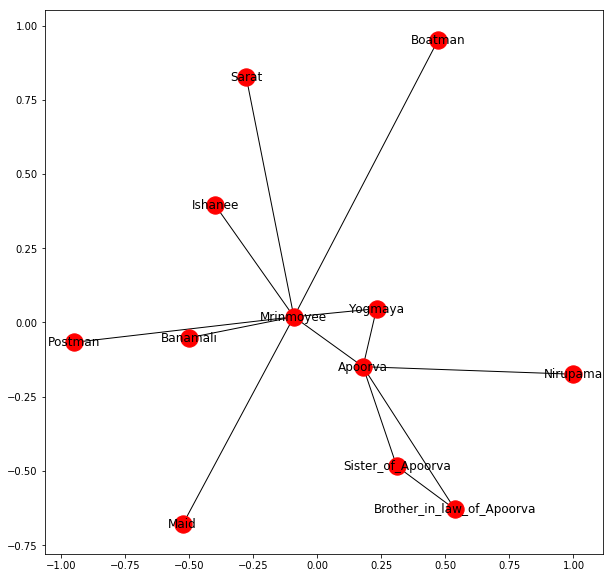

[[('Mrinmoyee', 'Mrinmoyee'), 0.14795918367346939], [('Mrinmoyee', 'Yogmaya'), 0.125], [('Mrinmoyee', 'Apoorva'), 0.6572066326530613], [('Mrinmoyee', 'Ishanee'), 0.0737404336734694], [('Mrinmoyee', 'Postman'), 0.029496173469387755], [('Mrinmoyee', 'Boatman'), 0.014748086734693877], [('Mrinmoyee', 'Banamali'), 0.08848852040816327], [('Mrinmoyee', 'Sarat'), 0.029496173469387755], [('Mrinmoyee', 'Maid'), 0.029496173469387755], [('Apoorva', 'Yogmaya'), 0.3875956632653061], [('Apoorva', 'Apoorva'), 0.01801658163265306], [('Apoorva', 'Nirupama'), 0.029974489795918362], [('Apoorva', 'Sister_of_Apoorva'), 0.15306122448979592], [('Apoorva', 'Brother_in_law_of_Apoorva'), 0.061224489795918366], [('Sister_of_Apoorva', 'Brother_in_law_of_Apoorva'), 0.05038265306122449]]


In [9]:
ss_4 = nx.read_weighted_edgelist('s_s_4.txt', delimiter=',')
print(nx.info(ss_4))

plt.figure(figsize = (10,10))
nx.draw_networkx(ss_4)
plt.show()

total_edge_weight = total_weight_of_G(ss_4) #NCF
w_ncf_4 = weighted_cness(ss_4,total_edge_weight)
print(w_ncf_4)

In [10]:
edge_w = list(w_ncf_4)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)\

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()
df_2.to_csv('s_s_t4.csv')

print(df_2)

                                             Edges        IF
0                           (Mrinmoyee, Mrinmoyee)  0.147959
1                             (Mrinmoyee, Yogmaya)  0.125000
2                             (Mrinmoyee, Apoorva)  0.657207
3                             (Mrinmoyee, Ishanee)  0.073740
4                             (Mrinmoyee, Postman)  0.029496
5                             (Mrinmoyee, Boatman)  0.014748
6                            (Mrinmoyee, Banamali)  0.088489
7                               (Mrinmoyee, Sarat)  0.029496
8                                (Mrinmoyee, Maid)  0.029496
9                               (Apoorva, Yogmaya)  0.387596
10                              (Apoorva, Apoorva)  0.018017
11                             (Apoorva, Nirupama)  0.029974
12                    (Apoorva, Sister_of_Apoorva)  0.153061
13            (Apoorva, Brother_in_law_of_Apoorva)  0.061224
14  (Sister_of_Apoorva, Brother_in_law_of_Apoorva)  0.050383
                        